In [3]:
import logging
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx
import json
from shapely.geometry import LineString

ox.settings.log_console = True

In [4]:
out_file_path = "ingolstadt_road_graph_square.json"

# Borders of the road network (rectangular)
west = 11.394562
south = 48.745380
east = 11.449351
north = 48.781047

### Data loading and initial check

In [5]:
bbox = (west, south, east, north)
G = ox.graph.graph_from_bbox(bbox, network_type="drive", retain_all=True)

In [6]:
G_proj = ox.project_graph(G)
nodes, edges = ox.graph_to_gdfs(G_proj)

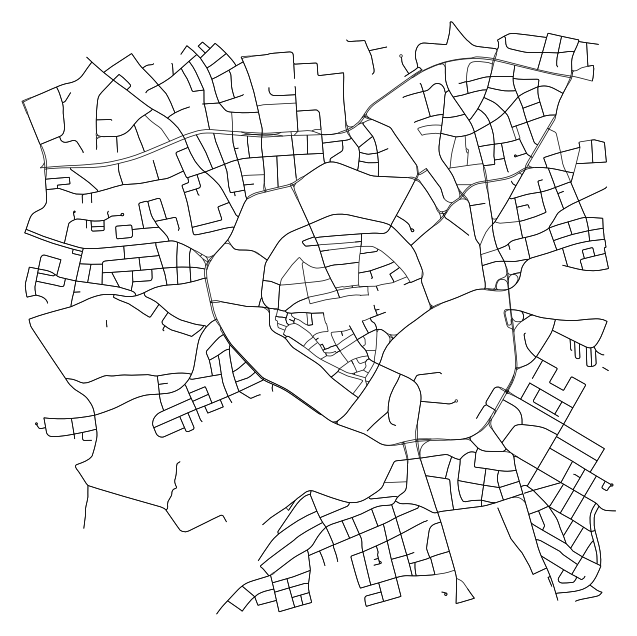

In [7]:
fig, ax = ox.plot_graph(
    G_proj,
    node_size=0,
    edge_linewidth=0.5,
    bgcolor="white",
    edge_color="black"
)

In [8]:
edges['highway'].value_counts()

highway
residential                      1519
tertiary                          390
secondary                         199
unclassified                      197
primary                           149
living_street                      97
primary_link                       27
tertiary_link                      17
secondary_link                     14
[living_street, residential]        8
[unclassified, residential]         2
[tertiary_link, primary_link]       2
busway                              2
Name: count, dtype: int64

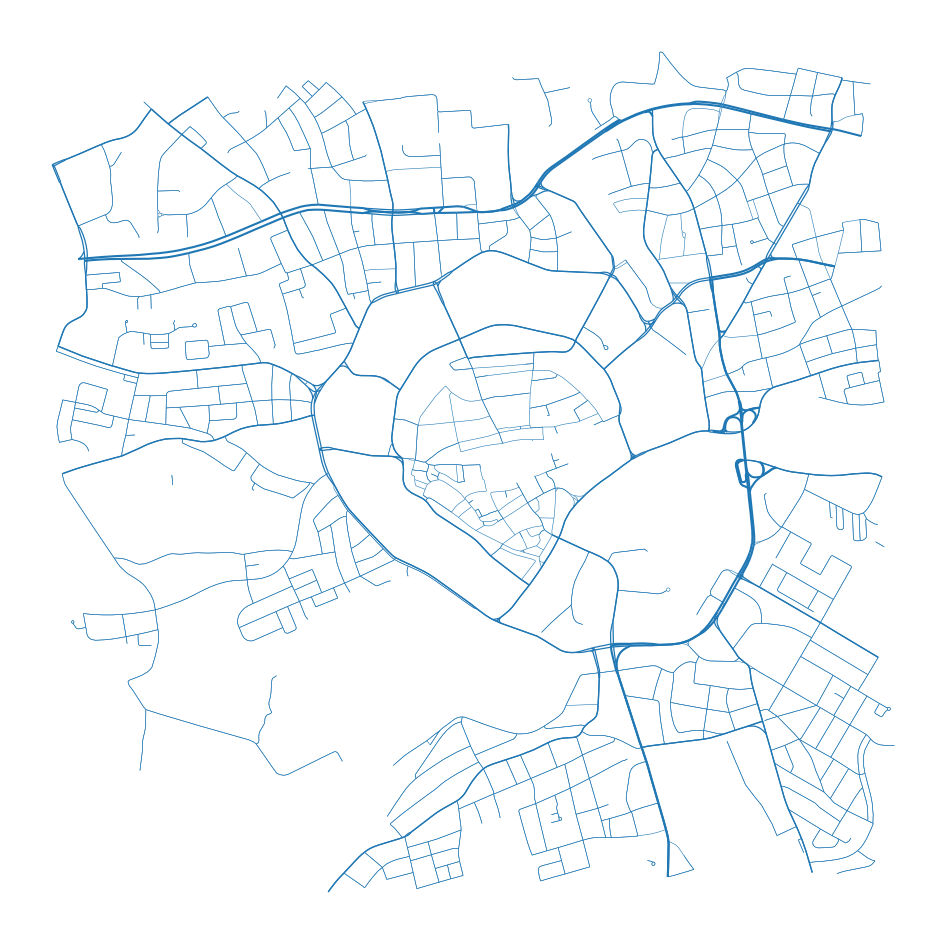

In [9]:
nodes, edges = ox.graph_to_gdfs(G_proj)

fig, ax = plt.subplots(figsize=(12, 12))

edges[edges["highway"].astype(str).str.contains("motorway|trunk|primary")].plot(
    ax=ax, linewidth=1.5#, color='r'
)

edges[edges["highway"].astype(str).str.contains("secondary|tertiary")].plot(
    ax=ax, linewidth=0.9
)

# edges[edges["highway"].astype(str).str.contains("residential|living_street|service")].plot(
#     ax=ax, linewidth=0.4
# )

edges[~(edges["highway"].astype(str).str.contains("motorway|trunk|primary|secondary|tertiary"))].plot(
    ax=ax, linewidth=0.4
)

ax.set_axis_off()
plt.show()

### Removing disconnected components

In [10]:
components = list(nx.weakly_connected_components(G_proj))
components = sorted(components, key=len, reverse=True)

len(components), [len(c) for c in components[:10]]

(9, [1068, 6, 3, 2, 2, 1, 1, 1, 1])

In [11]:
node_to_component = {}

for component_id, component_nodes in enumerate(components):
    for node_id in component_nodes:
        node_to_component[node_id] = component_id

nx.set_node_attributes(G_proj, node_to_component, "component_id")

In [12]:
edge_to_component = {}

for u, v, k in G_proj.edges(keys=True):
    edge_to_component[(u, v, k)] = node_to_component[u]

nx.set_edge_attributes(G_proj, edge_to_component, "component_id")

In [13]:
largest_nodes = components[0]

G_main = G_proj.subgraph(largest_nodes).copy()

In [14]:
def plot_network(G_proj, ax_=None, color=None):
    nodes, edges = ox.graph_to_gdfs(G_proj)
    
    if not ax_:
        fig, ax = plt.subplots(figsize=(12, 12))
    else:
        ax = ax_

    if color:
        edges[edges["highway"].astype(str).str.contains("motorway|trunk|primary")].plot(
            ax=ax, linewidth=1.5, color=color
        )
        
        edges[edges["highway"].astype(str).str.contains("secondary|tertiary")].plot(
            ax=ax, linewidth=0.9, color=color
        )
        
        edges[~(edges["highway"].astype(str).str.contains("motorway|trunk|primary|secondary|tertiary"))].plot(
            ax=ax, linewidth=0.4, color=color
        )
    else:
        edges[edges["highway"].astype(str).str.contains("motorway|trunk|primary")].plot(
            ax=ax, linewidth=1.5
        )
        
        edges[edges["highway"].astype(str).str.contains("secondary|tertiary")].plot(
            ax=ax, linewidth=0.9
        )
        
        edges[~(edges["highway"].astype(str).str.contains("motorway|trunk|primary|secondary|tertiary"))].plot(
            ax=ax, linewidth=0.4
        )

    return ax

In [15]:
nodes, edges = ox.graph_to_gdfs(G_proj)

main_edges = edges[edges["component_id"] == 0]
other_edges = edges[edges["component_id"] != 0]

main_nodes = nodes[nodes["component_id"] == 0]
other_nodes = nodes[nodes["component_id"] != 0]

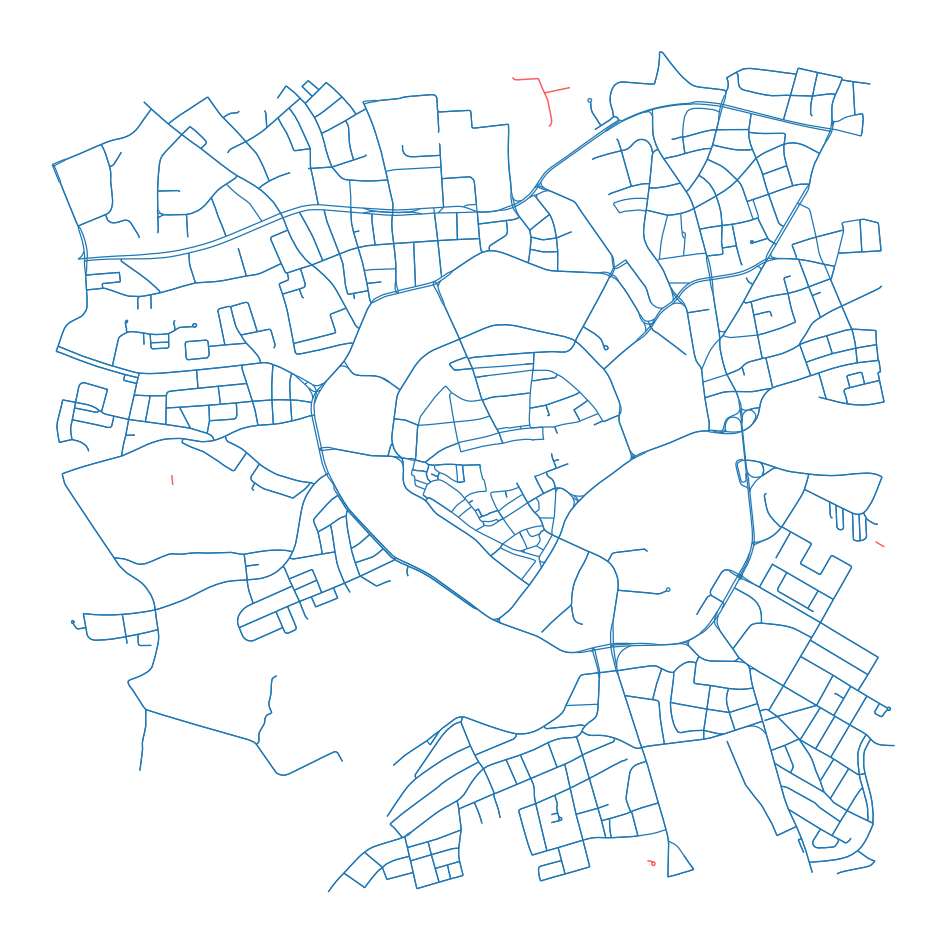

In [16]:
ax = other_edges.plot(figsize=(12, 12), linewidth=1, alpha=0.4, color='r')
main_edges.plot(ax=ax, linewidth=0.9)

# ax = plot_network(G_main, ax_=None)
# other_nodes.plot(ax=ax, markersize=5, color='r')

ax.set_axis_off()
plt.show()

In [17]:
nodes, edges = ox.graph_to_gdfs(G_main)

### Export to JSON

In [18]:
def to_unity_point(x, y, origin_x, origin_y):
    # Unity: X = east-west, Z = north-south, Y = height
    return {
        "x": float(x - origin_x),
        "y": 0.0,
        "z": float(y - origin_y)
    }


def parse_lanes(value, default=2):
    try:
        if isinstance(value, list):
            value = value[0]
        return int(str(value).split(";")[0])
    except:
        return default


def parse_speed(value, default=50):
    try:
        if isinstance(value, list):
            value = value[0]
        return float(str(value).split()[0])
    except:
        return default

In [19]:
x0 = nodes.geometry.x.mean()
y0 = nodes.geometry.y.mean()

print("Unity origin:", x0, y0)

Unity origin: 678270.9835524954 5404181.847176774


In [20]:
road_nodes = []

for node_id, row in nodes.iterrows():
    road_nodes.append({
        "id": int(node_id),
        "position": to_unity_point(row.geometry.x, row.geometry.y, x0, y0)
    })

In [21]:
road_edges = []

for (u, v, k), row in edges.iterrows():
    geom = row.geometry

    # fallback for edges without stored geometry
    if geom is None:
        p1 = nodes.loc[u].geometry
        p2 = nodes.loc[v].geometry
        geom = LineString([p1, p2])

    centerline = [
        to_unity_point(x, y, x0, y0)
        for x, y in geom.coords
    ]

    highway = row.get("highway", "unknown")
    if isinstance(highway, list):
        highway = highway[0]

    oneway = bool(row.get("oneway", False))

    road_edges.append({
        "id": f"{u}_{v}_{k}",
        "from": int(u),
        "to": int(v),
        "key": int(k),
        "centerline": centerline,
        "highway": str(highway),
        "lanes": parse_lanes(row.get("lanes", 2)),
        "maxspeed": parse_speed(row.get("maxspeed", 50)),
        "oneway": oneway,
        "length": float(row.get("length", geom.length)),
        "simulate": True
    })

In [22]:
export_data = {
    "metadata": {
        "source": "OpenStreetMap via OSMnx",
        "crs": str(nodes.crs),
        "origin_x": float(x0),
        "origin_y": float(y0),
        "unity_axes": "x=easting, y=height, z=northing",
        "unity_alignment": {
            "position": {
                "x": 0.0,
                "y": 0.0,
                "z": 0.0
            },
            "rotation_y": 0.0,
            "scale": 1.0
        }
    },
    "nodes": road_nodes,
    "edges": road_edges
}

with open(out_file_path, "w", encoding="utf-8") as f:
    json.dump(export_data, f, ensure_ascii=False)

print("Exported:", len(road_nodes), "nodes,", len(road_edges), "edges")

Exported: 1068 nodes, 2603 edges
